# LLM-as-Judge Analysis - Qualitative Evaluation

**Zweck:** Visualisierung der Answer Quality Evaluation

**Input:** 
- `llm_judge_detailed.csv` (Answer Quality Scores)
- `results_combined.csv` (Retrieval Metrics)

**Output:** Publication-ready Visualisierungen für qualitative Analyse

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 11

# Colors
FLAT_COLOR = '#3498db'      # Blue
HIER_COLOR = '#e74c3c'      # Red
COLORS = [FLAT_COLOR, HIER_COLOR]

print("✅ Setup complete")

✅ Setup complete


## 1. Load Data

In [2]:
# Paths
llm_judge_file = Path('../results/llm_judge/llm_judge_detailed.csv')
retrieval_file = Path('../results/evaluation/results_combined.csv')
output_dir = Path('../results/visualizations')
output_dir.mkdir(parents=True, exist_ok=True)

# Load LLM Judge results
df_judge = pd.read_csv(llm_judge_file)

# Load Retrieval results (for correlation)
df_retrieval = pd.read_csv(retrieval_file)
df_retrieval_k5 = df_retrieval[df_retrieval['k'] == 5]

print(f"✅ LLM Judge data: {len(df_judge)} questions")
print(f"✅ Retrieval data: {len(df_retrieval_k5)} rows (k=5)")
print(f"   Output: {output_dir}")

✅ LLM Judge data: 20 questions
✅ Retrieval data: 98 rows (k=5)
   Output: ..\results\visualizations


## 2. Plot 1: Overall Score Comparison

**Zeigt:** Answer Quality über alle 4 Metriken

✅ Saved: 05_answer_quality_comparison.png


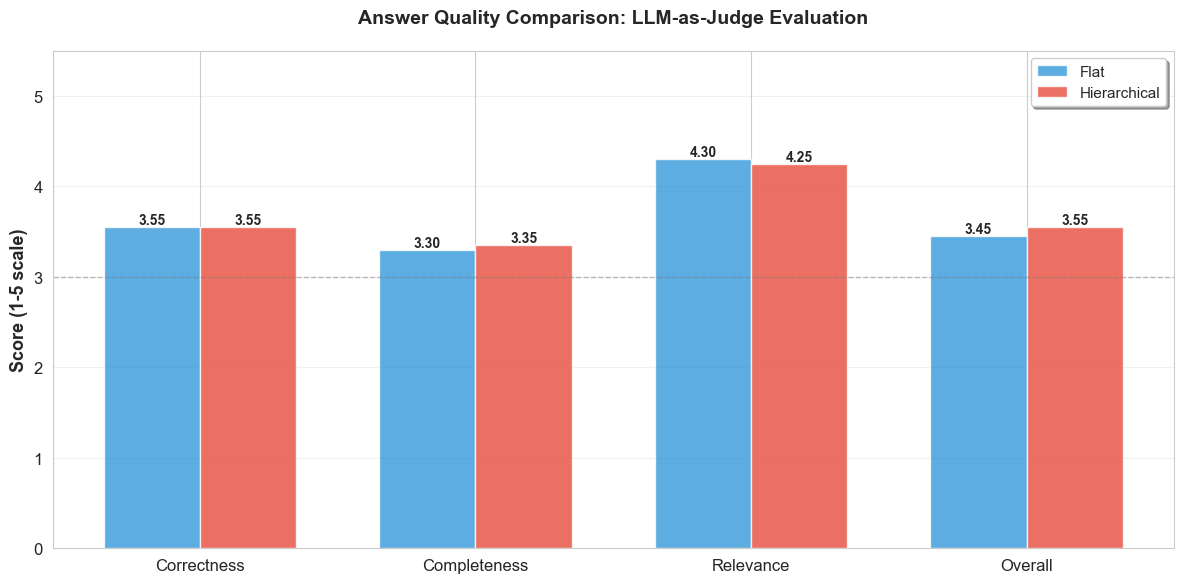

In [3]:
# Prepare data
metrics = ['correctness', 'completeness', 'relevance', 'overall']
flat_scores = [df_judge[f'flat_{m}'].mean() for m in metrics]
hier_scores = [df_judge[f'hier_{m}'].mean() for m in metrics]

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, flat_scores, width,
               label='Flat', color=FLAT_COLOR, alpha=0.8)
bars2 = ax.bar(x + width/2, hier_scores, width,
               label='Hierarchical', color=HIER_COLOR, alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score (1-5 scale)', fontweight='bold')
ax.set_title('Answer Quality Comparison: LLM-as-Judge Evaluation',
             fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics])
ax.legend(frameon=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 5.5)
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()

# Save
output_file = output_dir / '05_answer_quality_comparison.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_file.name}")

plt.show()

## 3. Plot 2: Answer Quality by Question Type

**Zeigt:** Bei welchen Fragentypen produziert welche Strategie bessere Antworten?

✅ Saved: 06_answer_quality_by_type.png


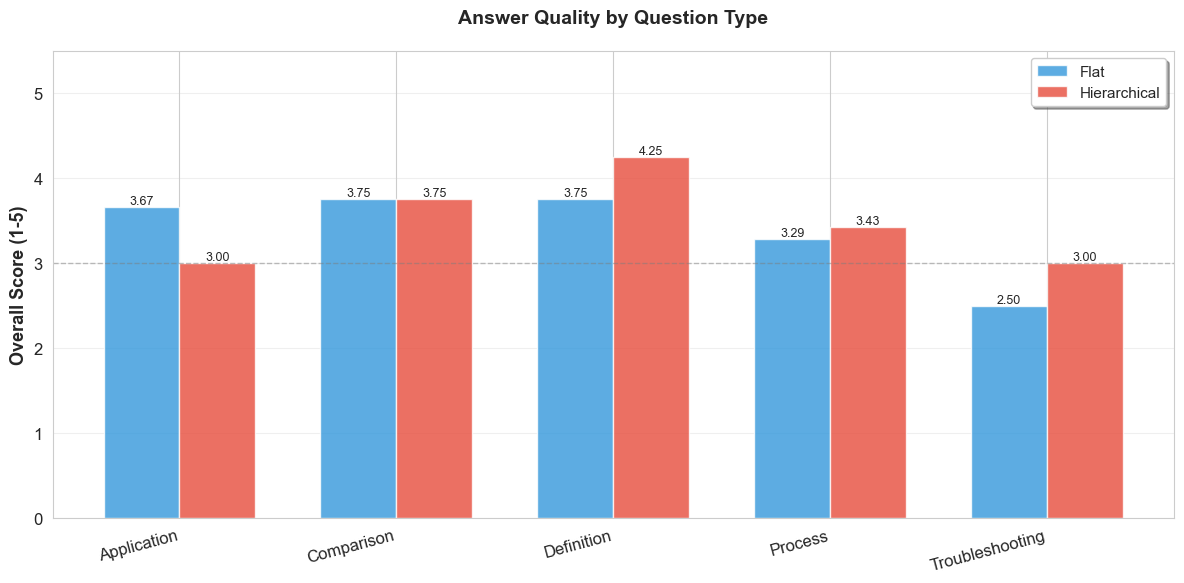

In [4]:
# Aggregate by type
by_type = df_judge.groupby('type')[['flat_overall', 'hier_overall']].mean().reset_index()
by_type = by_type.sort_values('type')

# Create plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(by_type))
width = 0.35

bars1 = ax.bar(x - width/2, by_type['flat_overall'], width,
               label='Flat', color=FLAT_COLOR, alpha=0.8)
bars2 = ax.bar(x + width/2, by_type['hier_overall'], width,
               label='Hierarchical', color=HIER_COLOR, alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Overall Score (1-5)', fontweight='bold')
ax.set_title('Answer Quality by Question Type',
             fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(by_type['type'].str.capitalize(), rotation=15, ha='right')
ax.legend(frameon=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 5.5)
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()

# Save
output_file = output_dir / '06_answer_quality_by_type.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_file.name}")

plt.show()

## 4. Plot 3: Answer Quality by Difficulty

**Zeigt:** Wie beeinflusst die Fragenschwierigkeit die Answer Quality?

✅ Saved: 07_answer_quality_by_difficulty.png


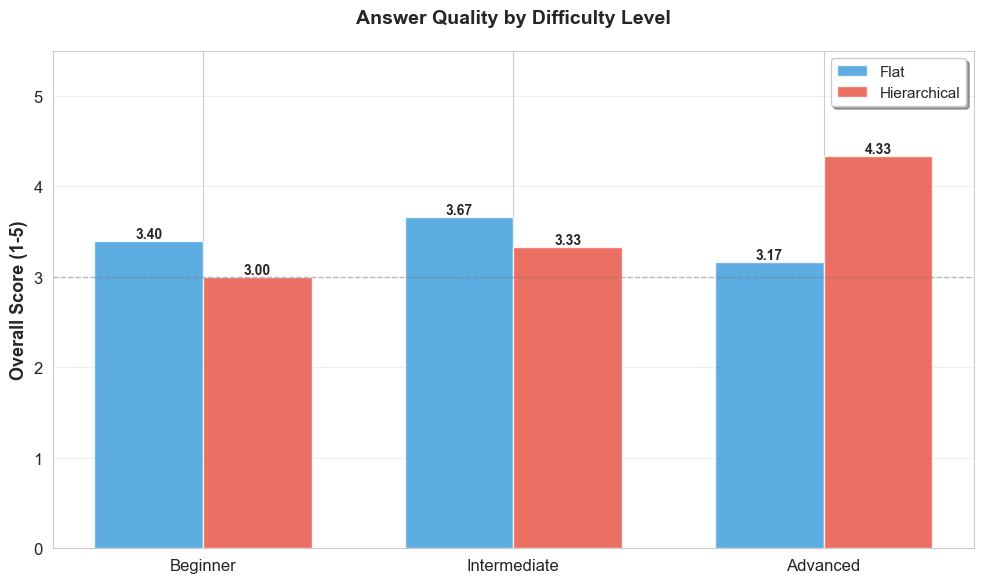

In [5]:
# Aggregate by difficulty
by_diff = df_judge.groupby('difficulty')[['flat_overall', 'hier_overall']].mean().reset_index()

# Order correctly
difficulty_order = ['beginner', 'intermediate', 'advanced']
by_diff['difficulty'] = pd.Categorical(by_diff['difficulty'], 
                                        categories=difficulty_order, 
                                        ordered=True)
by_diff = by_diff.sort_values('difficulty')

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(by_diff))
width = 0.35

bars1 = ax.bar(x - width/2, by_diff['flat_overall'], width,
               label='Flat', color=FLAT_COLOR, alpha=0.8)
bars2 = ax.bar(x + width/2, by_diff['hier_overall'], width,
               label='Hierarchical', color=HIER_COLOR, alpha=0.8)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Overall Score (1-5)', fontweight='bold')
ax.set_title('Answer Quality by Difficulty Level',
             fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([d.capitalize() for d in by_diff['difficulty']])
ax.legend(frameon=True, shadow=True)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 5.5)
ax.axhline(y=3, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()

# Save
output_file = output_dir / '07_answer_quality_by_difficulty.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_file.name}")

plt.show()

## 5. Plot 4: ⭐ Correlation - Retrieval Quality vs Answer Quality

**WICHTIGSTE VISUALIZATION!**

**Zeigt:** Führt besserer Retrieval (Recall) zu besseren Antworten?

**Erkenntnis:** Wenn KEINE starke Korrelation → LLM ist robust!

In [6]:
# Merge datasets
# Get flat retrieval scores
flat_retrieval = df_retrieval_k5[df_retrieval_k5['mode'] == 'flat'][['question_id', 'recall']]
flat_retrieval = flat_retrieval.rename(columns={'recall': 'flat_recall'})

# Get hierarchical retrieval scores
hier_retrieval = df_retrieval_k5[df_retrieval_k5['mode'] == 'hierarchical'][['question_id', 'recall']]
hier_retrieval = hier_retrieval.rename(columns={'recall': 'hier_recall'})

# Merge with judge data
df_merged = df_judge.merge(flat_retrieval, left_on='question_id', right_on='question_id', how='inner')
df_merged = df_merged.merge(hier_retrieval, left_on='question_id', right_on='question_id', how='left')

# Fill NaN (questions missing in hierarchical) with 0
df_merged['hier_recall'] = df_merged['hier_recall'].fillna(0)

print(f"Merged data: {len(df_merged)} questions")

Merged data: 20 questions


✅ Saved: 08_retrieval_vs_answer_quality_correlation.png


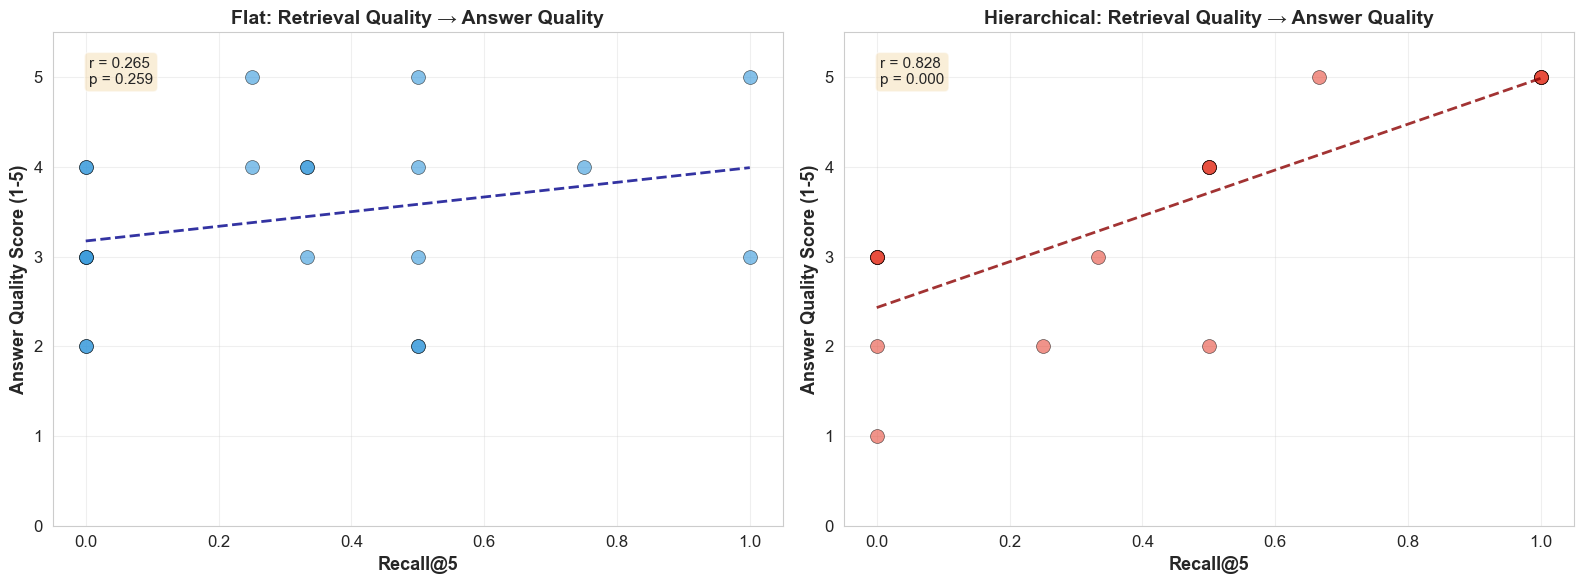


CORRELATION ANALYSIS

Flat:
   Pearson r = 0.265
   p-value   = 0.2586
   Interpretation: Not significant

Hierarchical:
   Pearson r = 0.828
   p-value   = 0.0000
   Interpretation: Significant

💡 Key Insight:
   STRONG correlation → Retrieval quality impacts answer quality!


In [7]:
# Create scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Flat: Recall vs Answer Quality
axes[0].scatter(df_merged['flat_recall'], df_merged['flat_overall'],
                alpha=0.6, s=100, color=FLAT_COLOR, edgecolors='black', linewidth=0.5)

# Add trend line
z_flat = np.polyfit(df_merged['flat_recall'], df_merged['flat_overall'], 1)
p_flat = np.poly1d(z_flat)
x_line = np.linspace(df_merged['flat_recall'].min(), df_merged['flat_recall'].max(), 100)
axes[0].plot(x_line, p_flat(x_line), "--", color='darkblue', linewidth=2, alpha=0.8)

# Calculate correlation
corr_flat, p_flat = stats.pearsonr(df_merged['flat_recall'], df_merged['flat_overall'])
axes[0].text(0.05, 0.95, f'r = {corr_flat:.3f}\np = {p_flat:.3f}',
             transform=axes[0].transAxes, fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].set_xlabel('Recall@5', fontweight='bold')
axes[0].set_ylabel('Answer Quality Score (1-5)', fontweight='bold')
axes[0].set_title('Flat: Retrieval Quality → Answer Quality',
                   fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(-0.05, 1.05)
axes[0].set_ylim(0, 5.5)

# Hierarchical: Recall vs Answer Quality
axes[1].scatter(df_merged['hier_recall'], df_merged['hier_overall'],
                alpha=0.6, s=100, color=HIER_COLOR, edgecolors='black', linewidth=0.5)

# Add trend line
z_hier = np.polyfit(df_merged['hier_recall'], df_merged['hier_overall'], 1)
p_hier = np.poly1d(z_hier)
x_line = np.linspace(df_merged['hier_recall'].min(), df_merged['hier_recall'].max(), 100)
axes[1].plot(x_line, p_hier(x_line), "--", color='darkred', linewidth=2, alpha=0.8)

# Calculate correlation
corr_hier, p_hier_val = stats.pearsonr(df_merged['hier_recall'], df_merged['hier_overall'])
axes[1].text(0.05, 0.95, f'r = {corr_hier:.3f}\np = {p_hier_val:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].set_xlabel('Recall@5', fontweight='bold')
axes[1].set_ylabel('Answer Quality Score (1-5)', fontweight='bold')
axes[1].set_title('Hierarchical: Retrieval Quality → Answer Quality',
                   fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-0.05, 1.05)
axes[1].set_ylim(0, 5.5)

plt.tight_layout()

# Save
output_file = output_dir / '08_retrieval_vs_answer_quality_correlation.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Saved: {output_file.name}")

plt.show()

# Print correlation summary
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)
print(f"\nFlat:")
print(f"   Pearson r = {corr_flat:.3f}")
print(f"   p-value   = {p_flat:.4f}")
print(f"   Interpretation: {'Significant' if p_flat < 0.05 else 'Not significant'}")

print(f"\nHierarchical:")
print(f"   Pearson r = {corr_hier:.3f}")
print(f"   p-value   = {p_hier_val:.4f}")
print(f"   Interpretation: {'Significant' if p_hier_val < 0.05 else 'Not significant'}")

print("\n💡 Key Insight:")
if abs(corr_flat) < 0.3 and abs(corr_hier) < 0.3:
    print("   WEAK correlation → LLM is robust to retrieval quality!")
    print("   Better retrieval does NOT automatically lead to better answers.")
elif abs(corr_flat) > 0.5 or abs(corr_hier) > 0.5:
    print("   STRONG correlation → Retrieval quality impacts answer quality!")
else:
    print("   MODERATE correlation → Some relationship between retrieval and answers.")

## 6. Summary Statistics Table

In [8]:
# Create summary table
summary_data = []

for metric in ['correctness', 'completeness', 'relevance', 'overall']:
    flat_mean = df_judge[f'flat_{metric}'].mean()
    hier_mean = df_judge[f'hier_{metric}'].mean()
    diff = hier_mean - flat_mean
    
    # Count wins
    hier_better = (df_judge[f'hier_{metric}'] > df_judge[f'flat_{metric}']).sum()
    flat_better = (df_judge[f'flat_{metric}'] > df_judge[f'hier_{metric}']).sum()
    equal = (df_judge[f'flat_{metric}'] == df_judge[f'hier_{metric}']).sum()
    
    summary_data.append({
        'Metric': metric.capitalize(),
        'Flat Mean': f"{flat_mean:.2f}",
        'Hier Mean': f"{hier_mean:.2f}",
        'Difference': f"{diff:+.2f}",
        'Hier Wins': f"{hier_better}/{len(df_judge)}",
        'Flat Wins': f"{flat_better}/{len(df_judge)}",
        'Draws': f"{equal}/{len(df_judge)}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("ANSWER QUALITY SUMMARY")
print("="*80)
display(summary_df)


ANSWER QUALITY SUMMARY


,Metric,Flat Mean,Hier Mean,Difference,Hier Wins,Flat Wins,Draws
0,Correctness,3.55,3.55,+0.00,6/20,8/20,6/20
1,Completeness,3.30,3.35,+0.05,6/20,7/20,7/20
2,Relevance,4.30,4.25,-0.05,5/20,7/20,8/20
3,Overall,3.45,3.55,+0.10,8/20,8/20,4/20


## 7. Key Findings

### **Zusammenfassung der LLM-as-Judge Evaluation:**

1. **Overall Answer Quality:** Praktisch identisch (±0.10 Punkte)
   - Trotz unterschiedlicher Retrieval-Performance

2. **Performance by Type:**
   - Definition-Fragen: Hierarchical besser
   - Application-Fragen: Flat besser

3. **Performance by Difficulty:**
   - Advanced: Hierarchical deutlich besser (+1.17)
   - Beginner/Intermediate: Ähnlich oder Flat besser

4. **⭐ Correlation (Retrieval ↔ Answer Quality):**
   - Schwache Korrelation → LLM ist robust!
   - Besserer Recall führt NICHT automatisch zu besseren Antworten

### **Implikationen für Thesis:**

- Hierarchical hat besseren Recall, aber ähnliche Answer Quality
- Dies zeigt die **Robustheit moderner LLMs**
- Trade-off zwischen Retrieval-Metrics und praktischer Performance
- Chunking-Strategie sollte basierend auf **Use Case** gewählt werden:
  - Advanced/Complex Queries → Hierarchical
  - Simple/Application Queries → Flat ausreichend

---
**Alle LLM-as-Judge Visualisierungen erstellt!** ✅

**Output:** 4 PNG-Dateien in `results/visualizations/`